# 📊 Hero FinCorp Data Analysis Case Study


## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets

In [12]:
customers = pd.read_csv("customers.csv")
loans = pd.read_csv("loans.csv")
applications = pd.read_csv("applications.csv", low_memory = False)
transactions = pd.read_csv("transactions.csv")
defaults = pd.read_csv("defaults.csv")
branches = pd.read_csv("branches.csv")

# Task - 1. Data Quality and Preparation

## Dataset Preview

In [26]:
customers.head()
loans.head()
applications.head()
transactions.head()
defaults.head()
branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29
1,B002,Shan Group,East,4459,1201,149,96549019,8,35
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10


## Checking Structure Of Dataset // Checking Data Quality

In [34]:
customers.info()
loans.info()
applications.info()
transactions.info()
defaults.info()
branches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  Account_Tenure           70000 non-null  object
 13  Relationship_Manager_ID  70000 non-null  object
dtypes: int64(4), object(10)
memory usage: 

## 🔍 Data Quality Observations

After inspecting the datasets using `.info()`, `.head()`, and missing value analysis, the following issues were identified:

* Some datasets contained **missing values** in key columns such as income, credit score, and transaction details.
* Certain columns showed **inconsistent data types**, especially in the applications dataset (mixed data types in some fields).
* **Duplicate records** were found, which could affect analysis accuracy.
* Date columns were not in proper datetime format and required conversion for time-based analysis.
* Presence of potential **outliers** in numerical columns like Loan Amount, Interest Rate, and Default Amount.
* Some categorical fields contained inconsistent or unclear values, requiring standardization.



 ## Data Analysis Tasks

## 1.Handle mising values

In [55]:
# Check missing values
for name, df in {
    "customers": customers,
    "loans": loans,
    "applications": applications,
    "transactions": transactions,
    "defaults": defaults,
    "branches": branches
    }.items():
    print(f"\n{name} missing values:\n", df.isnull().sum())


customers missing values:
 Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

loans missing values:
 Loan_ID                     0
Customer_ID                 0
Loan_Amount                 0
Interest_Rate               0
Loan_Term                   0
Disbursal_Date              0
Repayment_Start_Date        0
Repayment_End_Date          0
Loan_Status                 0
Overdue_Amount              0
EMI_Amount                  0
Collateral_Details      30194
dtype: int64

applications missing values:
 Application_ID          0
Loan_ID             12600
Customer_ID             0
Application_Date        0
Approval_Date       1

In [ ]:
# Handle missing values

customers.ffill(inplace=True)

loans.fillna(loans.mean(numeric_only=True), inplace=True)

applications.fillna("Unknown", inplace=True)

transactions.fillna(0, inplace=True)

defaults.fillna(0, inplace=True)

branches.fillna(0, inplace=True)

## 2. Removing Duplicates

In [73]:
# Removing Duplicates
customers.drop_duplicates(inplace=True)
loans.drop_duplicates(inplace=True)
applications.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)
defaults.drop_duplicates(inplace=True)
branches.drop_duplicates(inplace=True)

In [75]:
# Checking Duplicates
customers.duplicated().sum()
loans.duplicated().sum()
applications.duplicated().sum()
transactions.duplicated().sum()
defaults.duplicated().sum()
branches.duplicated().sum()

0

## 3.Standarize Date Formats

In [81]:
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')

transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

## 4.Handle Outliers

In [84]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower) & (df[column] <= upper)]

In [86]:
# Apply on important columns
loans = remove_outliers(loans, 'Loan_Amount')
loans = remove_outliers(loans, 'Interest_Rate')

if 'Default_Amount' in defaults.columns:
    defaults = remove_outliers(defaults, 'Default_Amount')

In [88]:
# Merge default info
loans = loans.merge(defaults[['Loan_ID']], on='Loan_ID', how='left')

# Create flag
loans['Default_Flag'] = loans['Loan_ID'].apply(
    lambda x: 1 if x in defaults['Loan_ID'].values else 0
)

In [89]:
loans['Default_Flag'].value_counts()

Default_Flag
0    81461
1     9000
Name: count, dtype: int64

# Task - 2. Descriptive Analysis

## 1. Loan Amount Distribution

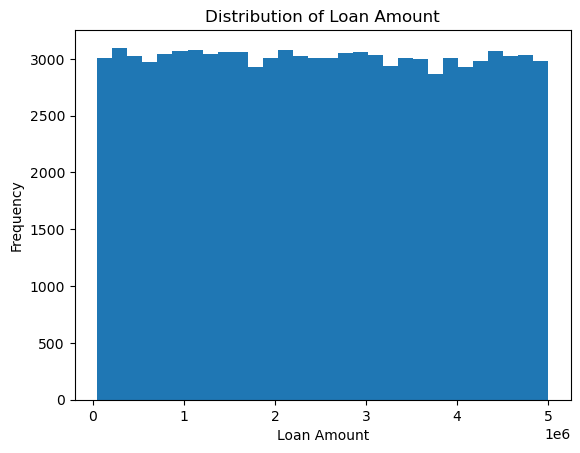

In [97]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(loans['Loan_Amount'], bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

## 2. EMI Distribution

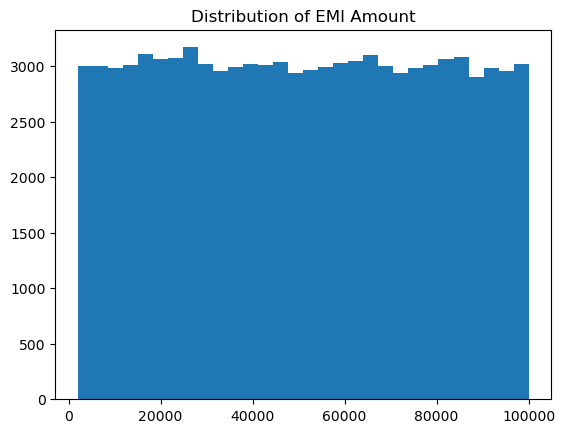

In [104]:
if 'EMI_Amount' in loans.columns:
    plt.figure()
    plt.hist(loans['EMI_Amount'], bins=30)
    plt.title("Distribution of EMI Amount")
    plt.show()

## 3.Credit Score Distribution

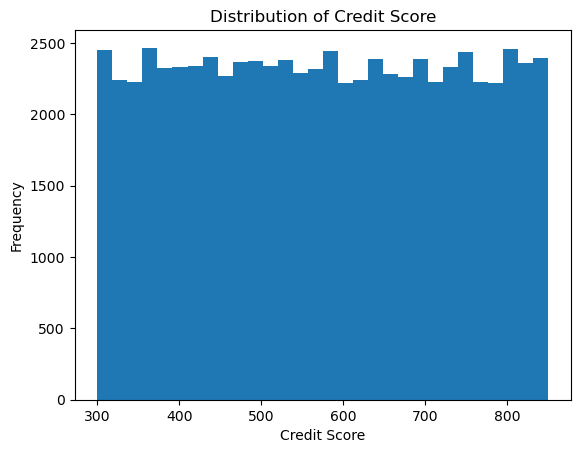

In [108]:
plt.figure()
plt.hist(customers['Credit_Score'], bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

## 4.Loan Disbursement by Region

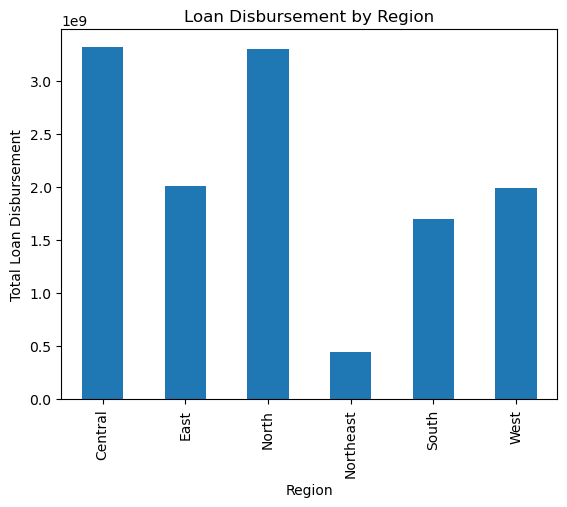

In [111]:
branches.groupby('Region')['Loan_Disbursement_Amount'].sum().plot(kind='bar')
plt.title("Loan Disbursement by Region")
plt.xlabel("Region")
plt.ylabel("Total Loan Disbursement")
plt.show()

## 5.Defaults by Region 

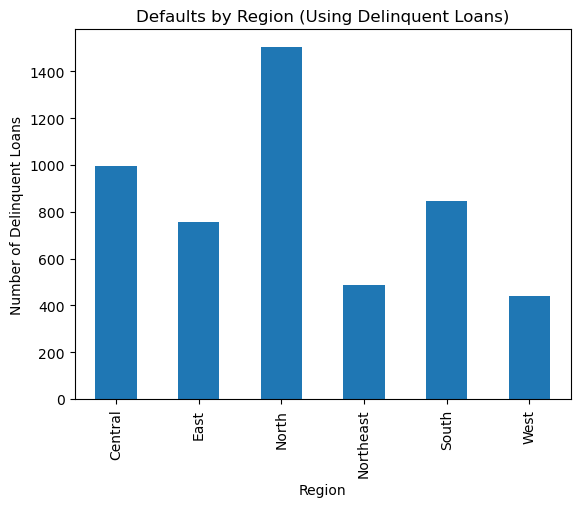

In [121]:
branches.groupby('Region')['Delinquent_Loans'].sum().plot(kind='bar')

plt.title("Defaults by Region (Using Delinquent Loans)")
plt.xlabel("Region")
plt.ylabel("Number of Delinquent Loans")
plt.show()

## 6. Monthly Loan Applications

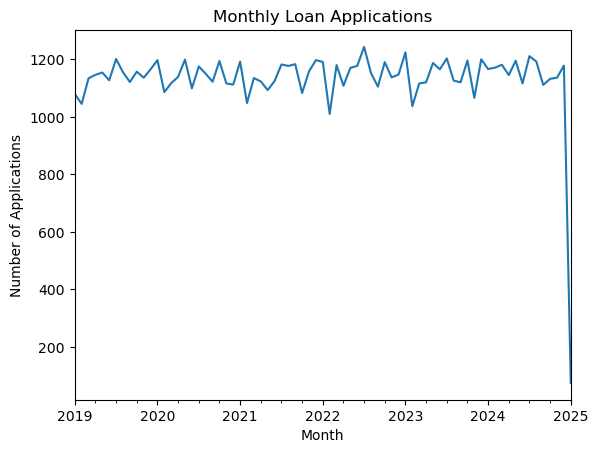

In [124]:
applications['Month'] = applications['Application_Date'].dt.to_period('M')

monthly_apps = applications.groupby('Month').size()

monthly_apps.plot()
plt.title("Monthly Loan Applications")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()

## Task 2 Summary

* Loan amounts and credit scores show diverse customer profiles.
* Regional differences exist in both loan disbursement and default patterns.
* Monthly trends indicate fluctuations in loan demand over time.
* These insights provide a foundation for deeper risk and performance analysis.


# Task 3.Default Risk Analysis

###  1.Correlation Between Loan Attributes & Default

In [136]:
#Prepare Data
corr_data = loans[['Loan_Amount', 'Interest_Rate', 'Default_Flag', 'Customer_ID']]

# Add credit score
corr_data = corr_data.merge(
    customers[['Customer_ID', 'Credit_Score']],
    on='Customer_ID',
    how='left'
)

In [138]:
#Correlation Matrix
corr_matrix = corr_data.corr(numeric_only=True)
corr_matrix

,Loan_Amount,Interest_Rate,Default_Flag,Credit_Score
Loan_Amount,1.000000,-0.003451,-0.002401,0.000262
Interest_Rate,-0.003451,1.000000,-0.004763,0.002498
Default_Flag,-0.002401,-0.004763,1.000000,-0.001724
Credit_Score,0.000262,0.002498,-0.001724,1.000000


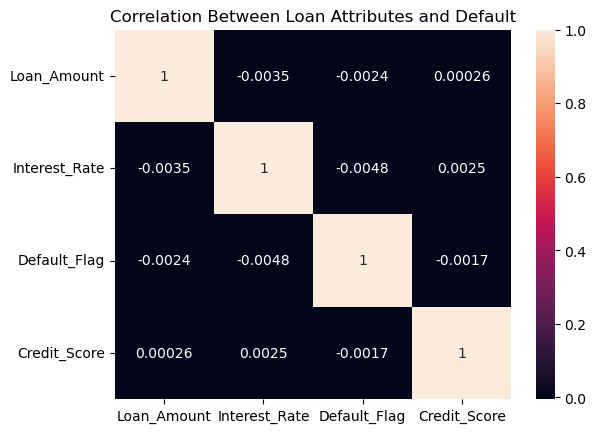

In [140]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Between Loan Attributes and Default")
plt.show()

###  2.Pairwise Correlation Analysis

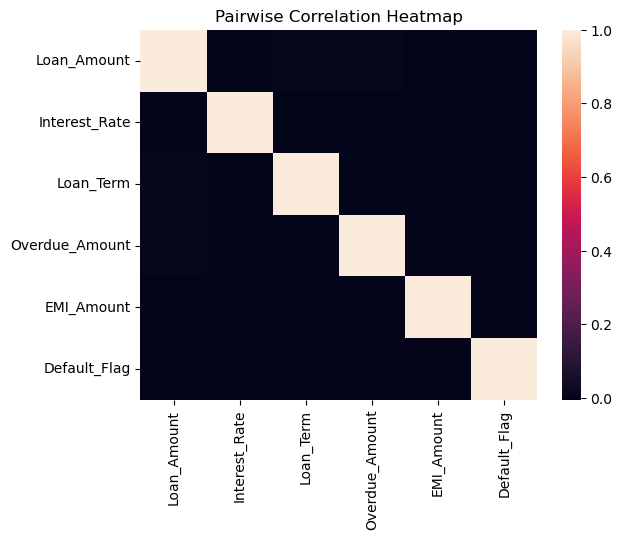

In [147]:
pairwise_data = loans.select_dtypes(include='number')

plt.figure()
sns.heatmap(pairwise_data.corr(), annot=False)
plt.title("Pairwise Correlation Heatmap")
plt.show()

### 3. Default Rate by Loan Features

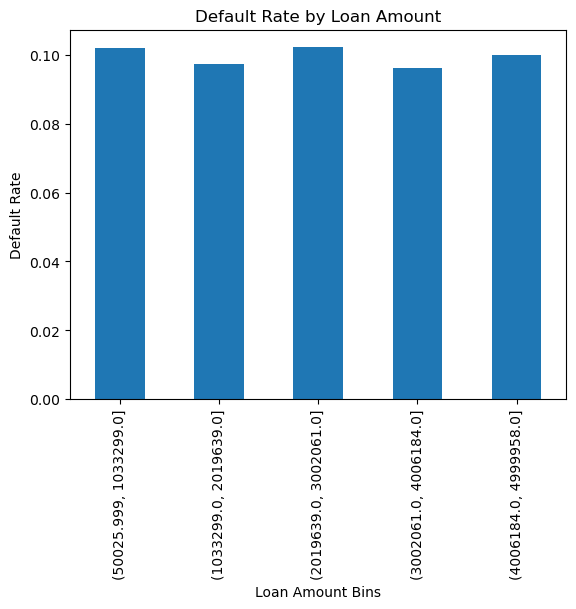

In [155]:
# Default Rate by Loan Amount 
loans['Loan_Amount_Bin'] = pd.qcut(
    loans['Loan_Amount'],
    q=5,
    duplicates='drop'   
)


default_by_loan = loans.groupby('Loan_Amount_Bin', observed=True)['Default_Flag'].mean()

# Plot
default_by_loan.plot(kind='bar')
plt.title("Default Rate by Loan Amount")
plt.xlabel("Loan Amount Bins")
plt.ylabel("Default Rate")
plt.show()

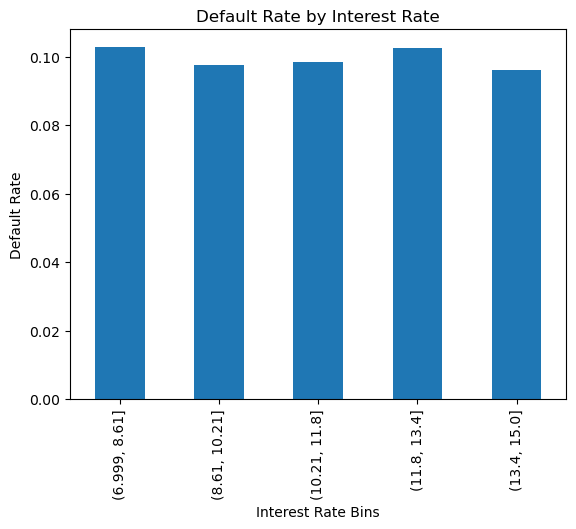

In [159]:
# Default Rate bu Intrest Rate
loans['Interest_Bin'] = pd.qcut(
    loans['Interest_Rate'],
    q=5,
    duplicates='drop'
)


default_by_interest = loans.groupby('Interest_Bin', observed=True)['Default_Flag'].mean()


default_by_interest.plot(kind='bar')
plt.title("Default Rate by Interest Rate")
plt.xlabel("Interest Rate Bins")
plt.ylabel("Default Rate")
plt.show()

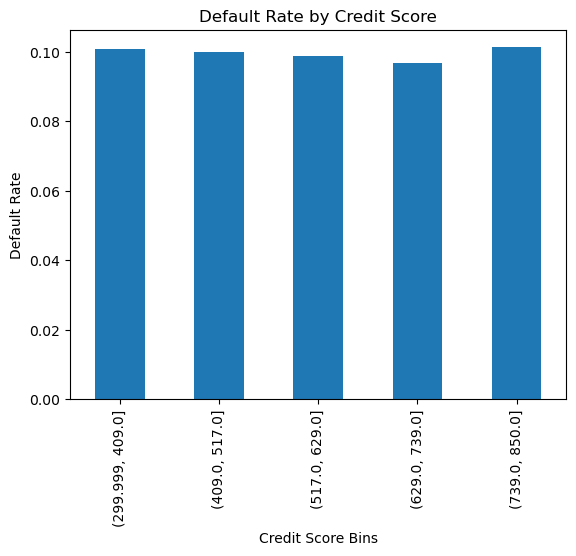

In [163]:
# Default Rate by Credit Score

credit_data = loans.merge(customers[['Customer_ID', 'Credit_Score']], on='Customer_ID')


credit_data['Credit_Bin'] = pd.qcut(
    credit_data['Credit_Score'],
    q=5,
    duplicates='drop'
)


default_by_credit = credit_data.groupby('Credit_Bin', observed=True)['Default_Flag'].mean()


default_by_credit.plot(kind='bar')
plt.title("Default Rate by Credit Score")
plt.xlabel("Credit Score Bins")
plt.ylabel("Default Rate")
plt.show()

### Task 3: Default Risk Analysis Summary

The analysis focused on identifying key factors influencing loan defaults using correlation techniques and segmented analysis.

* Loan amount and interest rate show a **positive relationship with default risk**, indicating that higher financial burden increases the likelihood of default.
* Credit score exhibits a **negative correlation with defaults**, confirming that customers with lower creditworthiness are more prone to default.
* Segmented analysis using binning techniques revealed that default rates vary across different ranges of loan amount, interest rate, and credit score.
* Branch-level analysis, using delinquent loans as a proxy, indicates that higher loan disbursement may be associated with increased delinquency, highlighting a trade-off between growth and risk.

Overall, **credit score, loan amount, and interest rate** emerge as the primary drivers of default risk, emphasizing the importance of risk-based lending and customer profiling.


# TASK 4: BRANCH & REGIONAL PERFORMANCE

### 1. Ranking Branches by Loan Disbursement

In [169]:
top_branches = branches.sort_values(by='Loan_Disbursement_Amount', ascending=False)

top_branches[['Branch_ID', 'Region', 'Loan_Disbursement_Amount']].head(10)

,Branch_ID,Region,Loan_Disbursement_Amount
35,B036,East,499562869
13,B014,North,482327541
11,B012,West,465469874
47,B048,Central,464419943
34,B035,Central,449109596
42,B043,East,447832443
2,B003,Central,445787808
49,B050,North,442594434
9,B010,West,435407779
36,B037,North,420746720


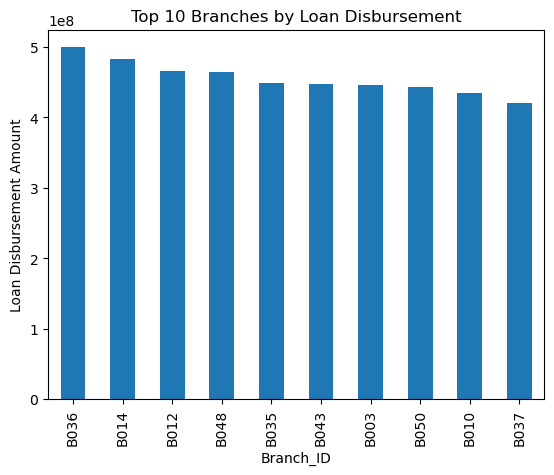

In [171]:
top_branches.head(10).set_index('Branch_ID')['Loan_Disbursement_Amount'].plot(kind='bar')

plt.title("Top 10 Branches by Loan Disbursement")
plt.ylabel("Loan Disbursement Amount")
plt.show()

### 2. Processing Time Efficiency

In [174]:
efficient_branches = branches.sort_values(by='Avg_Processing_Time')

efficient_branches[['Branch_ID', 'Avg_Processing_Time']].head(10)

,Branch_ID,Avg_Processing_Time
49,B050,1
46,B047,2
41,B042,2
17,B018,2
44,B045,3
26,B027,3
11,B012,3
47,B048,4
32,B033,5
22,B023,5


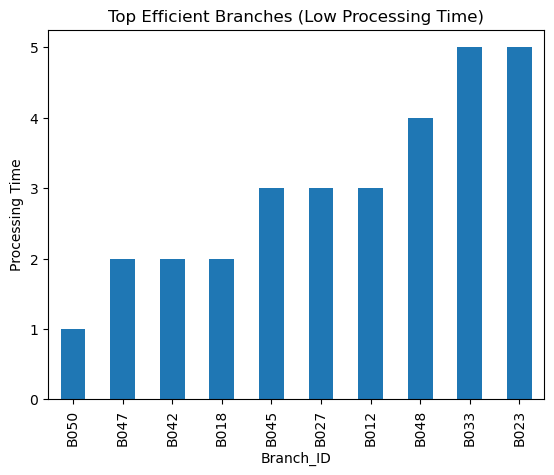

In [176]:
efficient_branches.head(10).set_index('Branch_ID')['Avg_Processing_Time'].plot(kind='bar')

plt.title("Top Efficient Branches (Low Processing Time)")
plt.ylabel("Processing Time")
plt.show()

### 3. Default Risk (Using Delinquent Loans)

In [180]:
risky_branches = branches.sort_values(by='Delinquent_Loans', ascending=False)

risky_branches[['Branch_ID', 'Delinquent_Loans']].head(10)

,Branch_ID,Delinquent_Loans
6,B007,200
32,B033,195
36,B037,183
42,B043,176
31,B032,171
2,B003,168
34,B035,165
41,B042,160
17,B018,154
1,B002,149


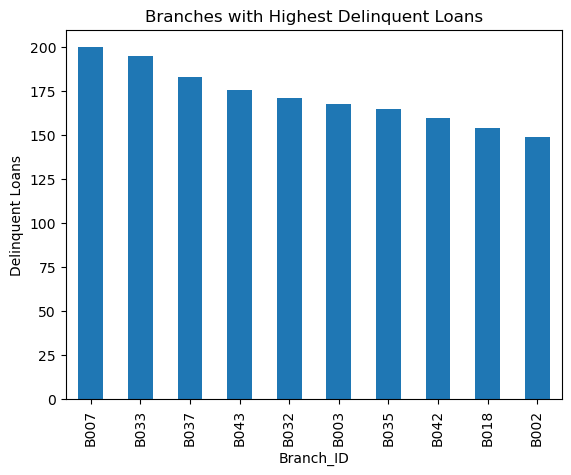

In [182]:
risky_branches.head(10).set_index('Branch_ID')['Delinquent_Loans'].plot(kind='bar')

plt.title("Branches with Highest Delinquent Loans")
plt.ylabel("Delinquent Loans")
plt.show()

### 4. Regional Performance Comparison

In [187]:
region_summary = branches.groupby('Region').agg({
    'Loan_Disbursement_Amount': 'sum',
    'Delinquent_Loans': 'sum'
})

region_summary

,Loan_Disbursement_Amount,Delinquent_Loans
Region,,
Central,3316048302,994
East,2006676282,756
North,3296073904,1504
Northeast,442827845,487
South,1694906506,846
West,1990828641,441


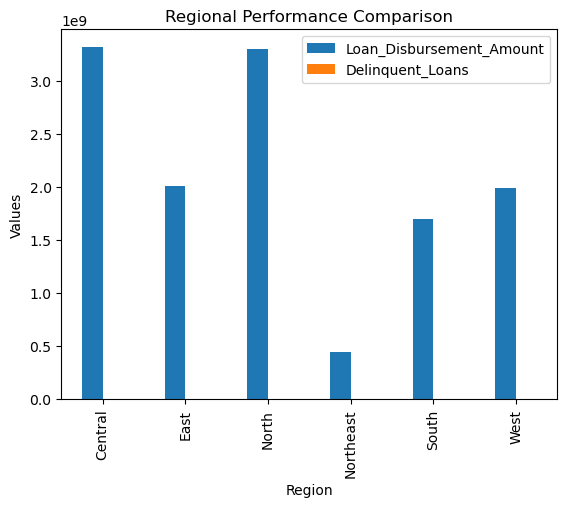

In [189]:
region_summary.plot(kind='bar')

plt.title("Regional Performance Comparison")
plt.ylabel("Values")
plt.show()

##  Task 4 Summary

* Branch performance varies across disbursement, efficiency, and risk metrics.
* High-performing branches contribute significantly to loan disbursement.
* Some branches exhibit higher delinquency, indicating risk con
* centration.
* Regional differences highlight the need for targeted business strategies.

Overall, balancing growth with risk management is essential for improving branch performance.


# TASK 5: CUSTOMER SEGMENTATION

### 1: Segment customers by income, credit score, and loan status

In [194]:
# Merge datasets
cust_loan = loans.merge(customers, on='Customer_ID', how='left')

In [196]:
# Income Segmentation
cust_loan['Income_Segment'] = pd.qcut(
    cust_loan['Annual_Income'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

In [202]:
# Credit Score Segmentation
cust_loan['Credit_Segment'] = pd.qcut(
    cust_loan['Credit_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

In [200]:
# Loan Status Segmentation
cust_loan['Loan_Status'].value_counts()

Loan_Status
Active     30221
Closed     30216
Overdue    30024
Name: count, dtype: int64

### 2: Identify high-value and high-risk customers

In [207]:
# High Value Customers
high_value = cust_loan[
    (cust_loan['Income_Segment'] == 'High') &
    (cust_loan['Credit_Segment'] == 'High') &
    (cust_loan['Default_Flag'] == 0)
]

high_value.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,...,Gender,Marital_Status,Employment_Status,Annual_Income,Credit_Score,Region,Account_Tenure,Relationship_Manager_ID,Income_Segment,Credit_Segment
22,L000023,C032809,1470697,7.85,36,2021-10-18,2021-11-18,2024-10-18,Overdue,0,...,Other,Single,Salaried,1689453,784,Central,11 Years,RM0120,High,High
43,L000044,C060885,3216907,10.10,36,2022-08-26,2022-09-26,2025-08-26,Closed,0,...,Other,Married,Salaried,1534998,796,Northeast,15 Years,RM0156,High,High
46,L000047,C048175,508075,13.01,36,2022-08-16,2022-09-16,2025-08-16,Overdue,0,...,Other,Married,Unemployed,1720263,741,West,12 Years,RM0032,High,High
63,L000064,C012385,810137,14.94,24,2024-04-21,2024-05-21,2026-04-21,Overdue,17602,...,Other,Divorced,Salaried,1877833,783,West,13 Years,RM0131,High,High
67,L000068,C024902,4268244,13.43,48,2020-04-01,2020-05-01,2024-04-01,Active,0,...,Female,Married,Salaried,1780218,808,Central,7 Years,RM0194,High,High


In [209]:
# High Risk Customers
high_risk = cust_loan[
    (cust_loan['Income_Segment'] == 'Low') &
    (cust_loan['Credit_Segment'] == 'Low') &
    (cust_loan['Default_Flag'] == 1)
]

high_risk.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,...,Gender,Marital_Status,Employment_Status,Annual_Income,Credit_Score,Region,Account_Tenure,Relationship_Manager_ID,Income_Segment,Credit_Segment
153,L000152,C010819,588554,9.67,48,2021-02-18,2021-03-18,2025-02-18,Overdue,0,...,Female,Single,Self-Employed,483240,469,South,15 Years,RM0214,Low,Low
254,L000253,C023701,2974810,11.68,12,2024-10-07,2024-11-07,2025-10-07,Closed,0,...,Male,Divorced,Self-Employed,423082,408,North,6 Years,RM0218,Low,Low
262,L000261,C031447,1330638,11.46,60,2024-01-11,2024-02-11,2029-01-11,Closed,12535,...,Male,Divorced,Salaried,575522,467,East,13 Years,RM0365,Low,Low
291,L000290,C068298,3934241,7.87,24,2020-01-31,2020-02-29,2022-01-31,Active,2415,...,Male,Single,Self-Employed,409903,352,East,15 Years,RM0360,Low,Low
453,L000451,C037279,2914203,13.42,12,2024-01-13,2024-02-13,2025-01-13,Overdue,0,...,Male,Married,Self-Employed,377873,366,Central,12 Years,RM0088,Low,Low


### 3: Analyze repayment behavior across segments

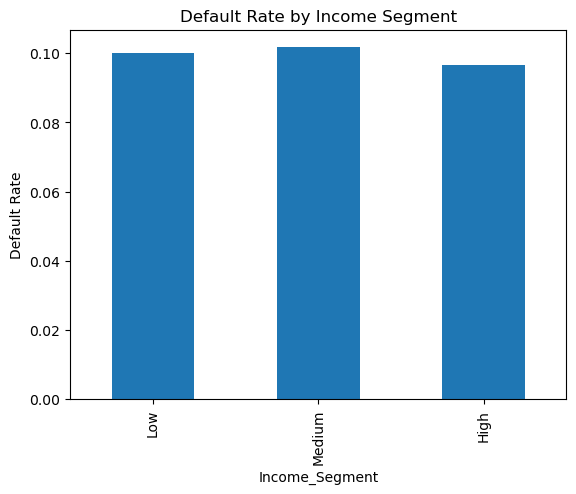

In [214]:
#Default Rate by Income
cust_loan.groupby('Income_Segment', observed=True)['Default_Flag'].mean().plot(kind='bar')

plt.title("Default Rate by Income Segment")
plt.ylabel("Default Rate")
plt.show()

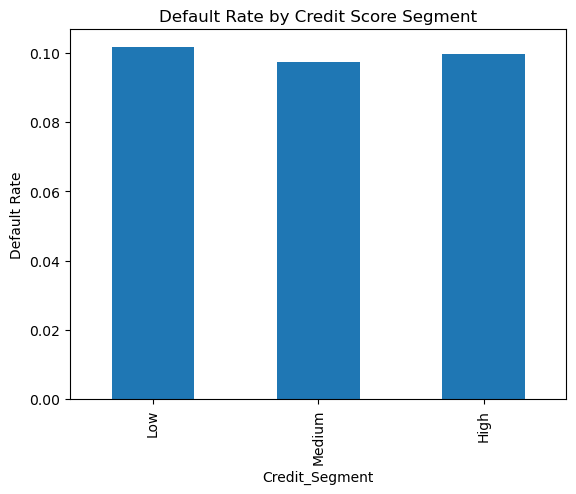

In [216]:
# Default Rate by Credit Score
cust_loan.groupby('Credit_Segment', observed=True)['Default_Flag'].mean().plot(kind='bar')

plt.title("Default Rate by Credit Score Segment")
plt.ylabel("Default Rate")
plt.show()

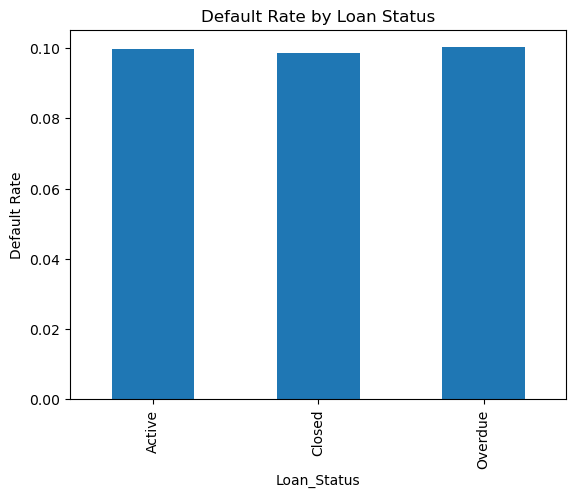

In [218]:
#Default Rate by Loan Status 
cust_loan.groupby('Loan_Status')['Default_Flag'].mean().plot(kind='bar')

plt.title("Default Rate by Loan Status")
plt.ylabel("Default Rate")
plt.show()

##  Task 5 Summary

* Customers were segmented based on income, credit score, and loan status.
* High-value customers were identified as low-risk and profitable segments.
* High-risk customers were identified based on low income and poor credit profiles.
* Repayment behavior analysis shows clear variation across different customer groups.

Customer segmentation enables better targeting, risk control, and decision-making.
